# Cross-Validation

## The problem with single split:
### -Result highly dependant on random split
### -Unreliabkle for small dataset
### -ist of overfitting to specific split

## Overfittting risk:
### -Model memorizes training data quirks instead of learning patterns

## Cross Validation Soluation
### -Multiple train test iterations
### -Uses entire dataset efficiently
### -Provides robust performance estimates

## KFold

### -Divide dataset inot k equal parts

### example: k=5

### Train on 4 folds->Test on 1 fold
### Repeat 5 times , rotating test fold
### Average performance across all folds

### advantages;
#### Reliable evaluation
#### Reduses Bias
#### Multiple iteration

#### Typical values : 5 or 10

In [6]:
x = [1,2,3,4,5,6,7,8,9]
y = [0,1,0,0,1,1,0,1,0]

In [7]:
from sklearn.model_selection import KFold

In [8]:
kf = KFold(n_splits=3)

In [9]:
for x_train,x_test in kf.split(x):
    print(x_train,x_test)

[3 4 5 6 7 8] [0 1 2]
[0 1 2 6 7 8] [3 4 5]
[0 1 2 3 4 5] [6 7 8]


## Stratified K-Fold

### -The problem : Imbalanced Data
### 90% class a
### 10% class B

### The soluation:
### Each fold maintains the originalk class proportion

### Advantages:
### Preserves Distribution
### handles imbalance
### Reliable for Classification
### Fair representation

### Default CV for classifiers in scikit-learn

In [10]:
from sklearn.model_selection import StratifiedKFold

In [12]:
sf = StratifiedKFold(n_splits=3)

In [13]:
sf.split(x,y)

<generator object _BaseKFold.split at 0x000001682E33B670>

In [14]:
for x_train,x_test in sf.split(x,y):
    print(x_train,x_test)
    

[3 4 5 6 7 8] [0 1 2]
[0 1 2 5 7 8] [3 4 6]
[0 1 2 3 4 6] [5 7 8]


In [15]:
import pandas as pd

In [16]:
import seaborn as sns

In [18]:
df = sns.load_dataset("iris")

In [20]:
df.head(10)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [21]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [22]:
df.shape

(150, 5)

In [23]:
x = df.iloc[:,:-1]
y= df.species

In [45]:
from sklearn.model_selection import StratifiedKFold

In [46]:
sf = StratifiedKFold(n_splits=5)

In [27]:
for train_index,test_index in sf.split(x,y):
    x_train,y_train=x.loc[train_index],y.loc[train_index]
    x_test,y_test=x.loc[test_index],y.loc[test_index]
    

In [72]:
for i in range(2,6):
    sf = StratifiedKFold(n_splits=i)
    for train_index,test_index in sf.split(x,y):
        x_train,y_train=x.loc[train_index],y.loc[train_index]
        x_test,y_test=x.loc[test_index],y.loc[test_index]
        print(x_train.shape,y_train.shape,x_test.shape,y_test.shape)

(75, 4) (75,) (75, 4) (75,)
(75, 4) (75,) (75, 4) (75,)
(100, 4) (100,) (50, 4) (50,)
(100, 4) (100,) (50, 4) (50,)
(100, 4) (100,) (50, 4) (50,)
(112, 4) (112,) (38, 4) (38,)
(112, 4) (112,) (38, 4) (38,)
(113, 4) (113,) (37, 4) (37,)
(113, 4) (113,) (37, 4) (37,)
(120, 4) (120,) (30, 4) (30,)
(120, 4) (120,) (30, 4) (30,)
(120, 4) (120,) (30, 4) (30,)
(120, 4) (120,) (30, 4) (30,)
(120, 4) (120,) (30, 4) (30,)


In [47]:
x_train.shape,y_train.shape,x_test.shape,y_test.shape

((113, 4), (113,), (37, 4), (37,))

In [48]:
from sklearn.linear_model import LogisticRegression

In [49]:
lr = LogisticRegression()

In [50]:
lr.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [51]:
lr.score(x_train,y_train),lr.score(x_test,y_test)

(0.9646017699115044, 1.0)

In [52]:
from sklearn.model_selection import cross_val_score

In [53]:
cv = cross_val_score(lr,x,y,cv=sf)

C:\Users\chaud\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [55]:
cv

array([0.96666667, 1.        , 0.93333333, 0.96666667, 1.        ])

In [61]:
avg = (cv.sum()/len(cv))*100

In [62]:
avg

np.float64(97.33333333333334)

In [42]:
ypred = lr.predict(x_test)

In [64]:
from sklearn.metrics import confusion_matrix

In [65]:
cm = confusion_matrix(y_test,ypred)

In [66]:
cm

array([[12,  0,  0],
       [ 0, 13,  0],
       [ 0,  0, 12]])

<Axes: >

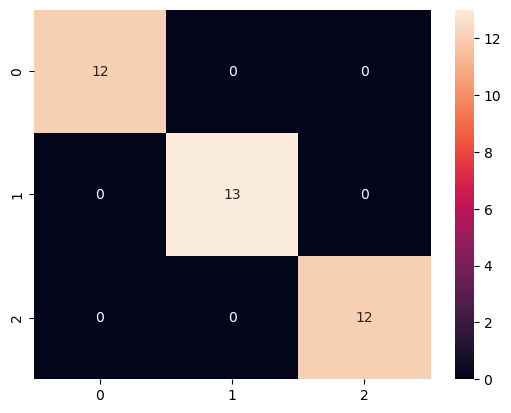

In [69]:
sns.heatmap(cm,annot=True)

In [70]:
from sklearn.metrics import classification_report

In [71]:
print(classification_report(y_test,ypred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        12

    accuracy                           1.00        37
   macro avg       1.00      1.00      1.00        37
weighted avg       1.00      1.00      1.00        37



In [1]:
import seaborn as sns

In [2]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [8]:
df = sns.load_dataset("penguins")

In [9]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [10]:
df.shape

(344, 7)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [12]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [13]:
df.dropna(inplace=True)

In [14]:
df.shape

(333, 7)

In [15]:
df.duplicated().sum()

np.int64(0)

<Axes: >

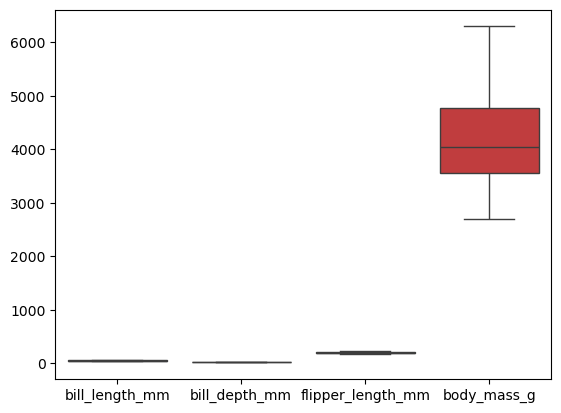

In [20]:
sns.boxplot(df[["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"]])

In [21]:
from sklearn.preprocessing import LabelEncoder

In [22]:
le = LabelEncoder()

In [23]:
df["sex"]=le.fit_transform(df["sex"])

In [24]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,1
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,0
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,0
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,1


In [25]:
df.drop("island",axis=1,inplace=True)

In [26]:
df.head()

,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,39.1,18.7,181.0,3750.0,1
1,Adelie,39.5,17.4,186.0,3800.0,0
2,Adelie,40.3,18.0,195.0,3250.0,0
4,Adelie,36.7,19.3,193.0,3450.0,0
5,Adelie,39.3,20.6,190.0,3650.0,1


In [27]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
count,333.000000,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057,0.504505
std,5.468668,1.969235,14.015765,805.215802,0.500732
min,32.100000,13.100000,172.000000,2700.000000,0.000000
25%,39.500000,15.600000,190.000000,3550.000000,0.000000
50%,44.500000,17.300000,197.000000,4050.000000,1.000000
75%,48.600000,18.700000,213.000000,4775.000000,1.000000
max,59.600000,21.500000,231.000000,6300.000000,1.000000


In [28]:
from sklearn.preprocessing import StandardScaler

In [29]:
ss = StandardScaler()

In [32]:
df["flipper_length_mm"] = ss.fit_transform(df[["flipper_length_mm"]])
df["body_mass_g"] = ss.fit_transform(df[["body_mass_g"]])

In [33]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
count,333.000000,333.000000,3.330000e+02,3.330000e+02,333.000000
mean,43.992793,17.164865,-8.535048e-17,-1.707010e-16,0.504505
std,5.468668,1.969235,1.001505e+00,1.001505e+00,0.500732
min,32.100000,13.100000,-2.069852e+00,-1.874435e+00,0.000000
25%,39.500000,15.600000,-7.836512e-01,-8.172292e-01,0.000000
50%,44.500000,17.300000,-2.834620e-01,-1.953432e-01,1.000000
75%,48.600000,18.700000,8.598276e-01,7.063915e-01,1.000000
max,59.600000,21.500000,2.146028e+00,2.603144e+00,1.000000


In [67]:
x= df.iloc[:,1:]
y = df.species

In [68]:
from imblearn.over_sampling import SMOTE

In [69]:
sm = SMOTE()

In [70]:
x,y = sm.fit_resample(x,y)

In [71]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [72]:
sf = StratifiedKFold(n_splits=5)

In [73]:
for train_index,test_index in sf.split(x,y):
    x_train,y_train=x.iloc[train_index],y.iloc[train_index]
    x_test,y_test=x.iloc[test_index],y.iloc[test_index]

In [74]:
from sklearn.tree import DecisionTreeClassifier

In [75]:
dc = DecisionTreeClassifier()

In [76]:
dc.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [77]:
dc.score(x_train,y_train),dc.score(x_test,y_test)

(1.0, 0.9885057471264368)

In [78]:
score = cross_val_score(dc,x,y,cv=5)

In [79]:
avgScore = score.mean()

In [80]:
avgScore

np.float64(0.9725966562173459)

In [81]:
y_pred= dc.predict(x_test)

In [82]:
y_pred

array(['Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie',
       'Gentoo', 'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie',
       'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie',
       'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie',
       'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Gentoo',
       'Gentoo', 'Chinstrap', 'Chinstrap', 'Chinstrap', 'Chinstrap',
       'Chinstrap', 'Chinstrap', 'Chinstrap', 'Chinstrap', 'Chinstrap',
       'Chinstrap', 'Chinstrap', 'Chinstrap', 'Chinstrap', 'Chinstrap',
       'Chinstrap', 'Chinstrap', 'Chinstrap', 'Chinstrap', 'Chinstrap',
       'Chinstrap', 'Chinstrap', 'Chinstrap', 'Chinstrap', 'Chinstrap',
       'Chinstrap', 'Chinstrap', 'Chinstrap', 'Chinstrap', 'Chinstrap',
       'Gentoo', 'Gentoo', 'Gentoo', 'Gentoo', 'Gentoo', 'Gentoo',
       'Gentoo', 'Gentoo', 'Gentoo', 'Gentoo', 'Gentoo', 'Gentoo',
       'Gentoo', 'Gentoo', 'Gentoo', 'Gentoo', 'Gentoo', 'Gentoo',
       'Gentoo', 'Gentoo', 'Gentoo'

In [83]:
y_test

117    Adelie
118    Adelie
119    Adelie
120    Adelie
121    Adelie
        ...  
433    Gentoo
434    Gentoo
435    Gentoo
436    Gentoo
437    Gentoo
Name: species, Length: 87, dtype: object

In [85]:
df

,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,39.1,18.7,-1.426752,-0.568475,1
1,Adelie,39.5,17.4,-1.069474,-0.506286,0
2,Adelie,40.3,18.0,-0.426373,-1.190361,0
4,Adelie,36.7,19.3,-0.569284,-0.941606,0
5,Adelie,39.3,20.6,-0.783651,-0.692852,1
...,...,...,...,...,...,...
338,Gentoo,47.2,13.7,0.931283,0.892957,0
340,Gentoo,46.8,14.3,1.002739,0.799674,0
341,Gentoo,50.4,15.7,1.502928,1.919069,1
342,Gentoo,45.2,14.8,0.788372,1.234995,0


In [91]:
dc.predict([[30.1,18.7,1.426752,0.5675,0]])

C:\Users\chaud\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array(['Adelie'], dtype=object)